In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('../data_collection/training_data.csv')

print(f"Dataset shape:    {df.shape}")
print(f"Unique handles:   {df['handle'].nunique()}")
print()
print("Column types:")
print(df.dtypes)
print()
print("First 5 rows:")
print(df.head())

Dataset shape:    (8646, 14)
Unique handles:   2164

Column types:
handle                     str
snapshot_date              str
current_rating           int64
solve_rate_per_week    float64
tag_diversity            int64
avg_problem_rating     float64
contest_frequency      float64
consistency_score      float64
weak_tag_count           int64
rating_volatility      float64
recent_performance     float64
total_ac_count           int64
label_3m                 int64
label_6m                 int64
dtype: object

First 5 rows:
     handle snapshot_date  current_rating  solve_rate_per_week  tag_diversity  \
0  5achinnn    2025-03-25            1177                20.48             20   
1  5achinnn    2025-05-24            1317                13.29             27   
2  5achinnn    2025-08-07            1244                10.55             29   
3  5achinnn    2025-12-23            1031                 7.58             29   
4  5achinnn    2026-02-25            1205                 7.89   

In [2]:
print("Missing values:")
print(df.isnull().sum())
print()

print("Basic statistics:")
print(df.describe())
print()

# Check for suspicious values
print("Rows with rating < 400:")
print(len(df[df['current_rating'] < 400]))

print("Rows with label_3m < 400:")
print(len(df[df['label_3m'] < 400]))

print("Rows with solve_rate_per_week > 200:")
print(len(df[df['solve_rate_per_week'] > 200]))

Missing values:
handle                 0
snapshot_date          0
current_rating         0
solve_rate_per_week    0
tag_diversity          0
avg_problem_rating     0
contest_frequency      0
consistency_score      0
weak_tag_count         0
rating_volatility      0
recent_performance     0
total_ac_count         0
label_3m               0
label_6m               0
dtype: int64

Basic statistics:
       current_rating  solve_rate_per_week  tag_diversity  avg_problem_rating  \
count     8646.000000          8646.000000    8646.000000         8646.000000   
mean      1416.807078             5.828705      25.008906         1186.169084   
std        382.016200             8.749206       6.738684          272.534404   
min        492.000000             0.070000       7.000000          800.000000   
25%       1125.000000             1.800000      20.000000          972.700000   
50%       1364.500000             3.810000      25.000000         1135.700000   
75%       1667.000000             7

In [3]:
print(f"Before cleaning: {len(df)} rows")

# Remove obviously bad rows
df = df[df['current_rating'] >= 400]
df = df[df['label_3m'] >= 400]
df = df[df['label_3m'] <= 4000]
df = df[df['solve_rate_per_week'] <= 100]
df = df[df['avg_problem_rating'] >= 400]

# Remove rows with any missing values
df = df.dropna()

print(f"After cleaning:  {len(df)} rows")
print(f"Removed:         {len(pd.read_csv('../data_collection/training_data.csv')) - len(df)} rows")

Before cleaning: 8646 rows
After cleaning:  8637 rows
Removed:         9 rows


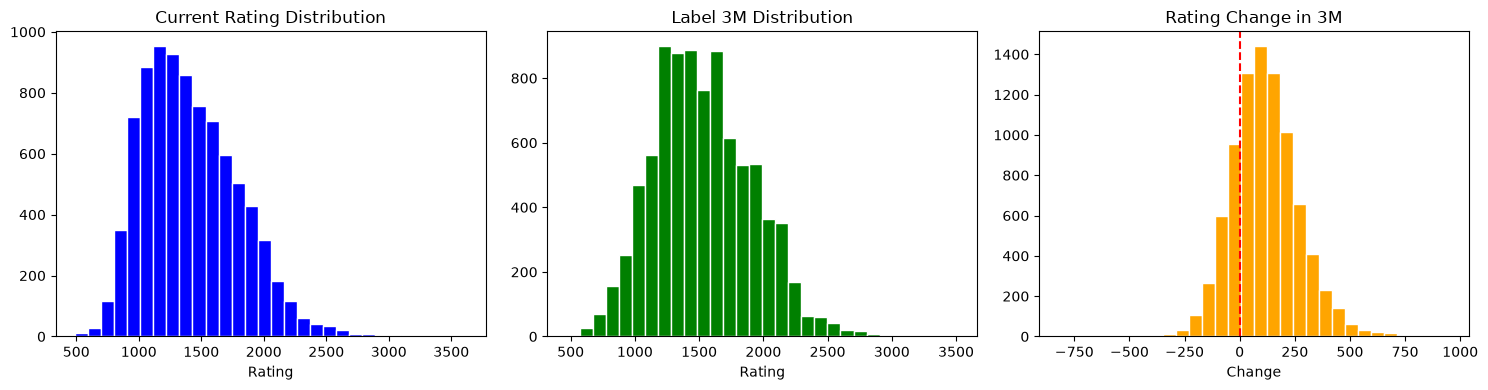

Average rating change in 3M: 115.8
Std of rating change:        153.3
Users who improved:          6747 (78.1%)
Users who declined:          1871 (21.7%)


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['current_rating'], bins=30, color='blue', edgecolor='white')
axes[0].set_title('Current Rating Distribution')
axes[0].set_xlabel('Rating')

axes[1].hist(df['label_3m'], bins=30, color='green', edgecolor='white')
axes[1].set_title('Label 3M Distribution')
axes[1].set_xlabel('Rating')

df['rating_change'] = df['label_3m'] - df['current_rating']
axes[2].hist(df['rating_change'], bins=30, color='orange', edgecolor='white')
axes[2].axvline(x=0, color='red', linestyle='--')
axes[2].set_title('Rating Change in 3M')
axes[2].set_xlabel('Change')

plt.tight_layout()
plt.show()

print(f"Average rating change in 3M: {df['rating_change'].mean():.1f}")
print(f"Std of rating change:        {df['rating_change'].std():.1f}")
print(f"Users who improved:          {(df['rating_change'] > 0).sum()} ({(df['rating_change'] > 0).mean()*100:.1f}%)")
print(f"Users who declined:          {(df['rating_change'] < 0).sum()} ({(df['rating_change'] < 0).mean()*100:.1f}%)")

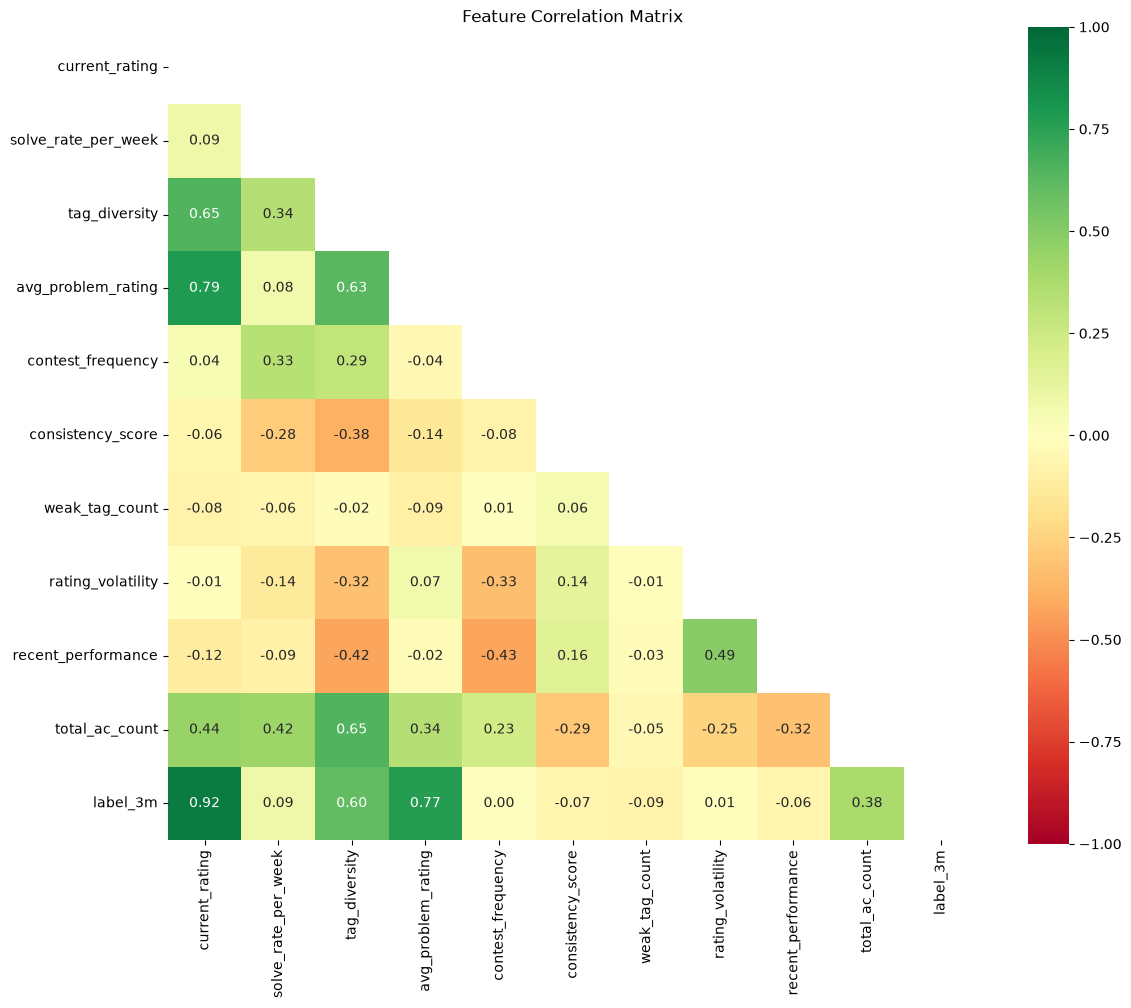

Correlations with label_3m (sorted):
  current_rating           : +0.920  ██████████████████
  avg_problem_rating       : +0.766  ███████████████
  tag_diversity            : +0.603  ████████████
  total_ac_count           : +0.380  ███████
  solve_rate_per_week      : +0.086  █
  rating_volatility        : +0.015  
  contest_frequency        : +0.003  
  recent_performance       : -0.065  █
  consistency_score        : -0.065  █
  weak_tag_count           : -0.085  █


In [5]:
features = [
    'current_rating', 'solve_rate_per_week', 'tag_diversity',
    'avg_problem_rating', 'contest_frequency', 'consistency_score',
    'weak_tag_count', 'rating_volatility', 'recent_performance',
    'total_ac_count', 'label_3m'
]

# Only use columns that exist in your dataset
available = [f for f in features if f in df.columns]

corr = df[available].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    mask=mask,
    vmin=-1,
    vmax=1,
    square=True
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Print correlations with label specifically
print("Correlations with label_3m (sorted):")
label_corr = corr['label_3m'].drop('label_3m').sort_values(ascending=False)
for feat, val in label_corr.items():
    bar  = '█' * int(abs(val) * 20)
    sign = '+' if val > 0 else '-'
    print(f"  {feat:25s}: {sign}{abs(val):.3f}  {bar}")

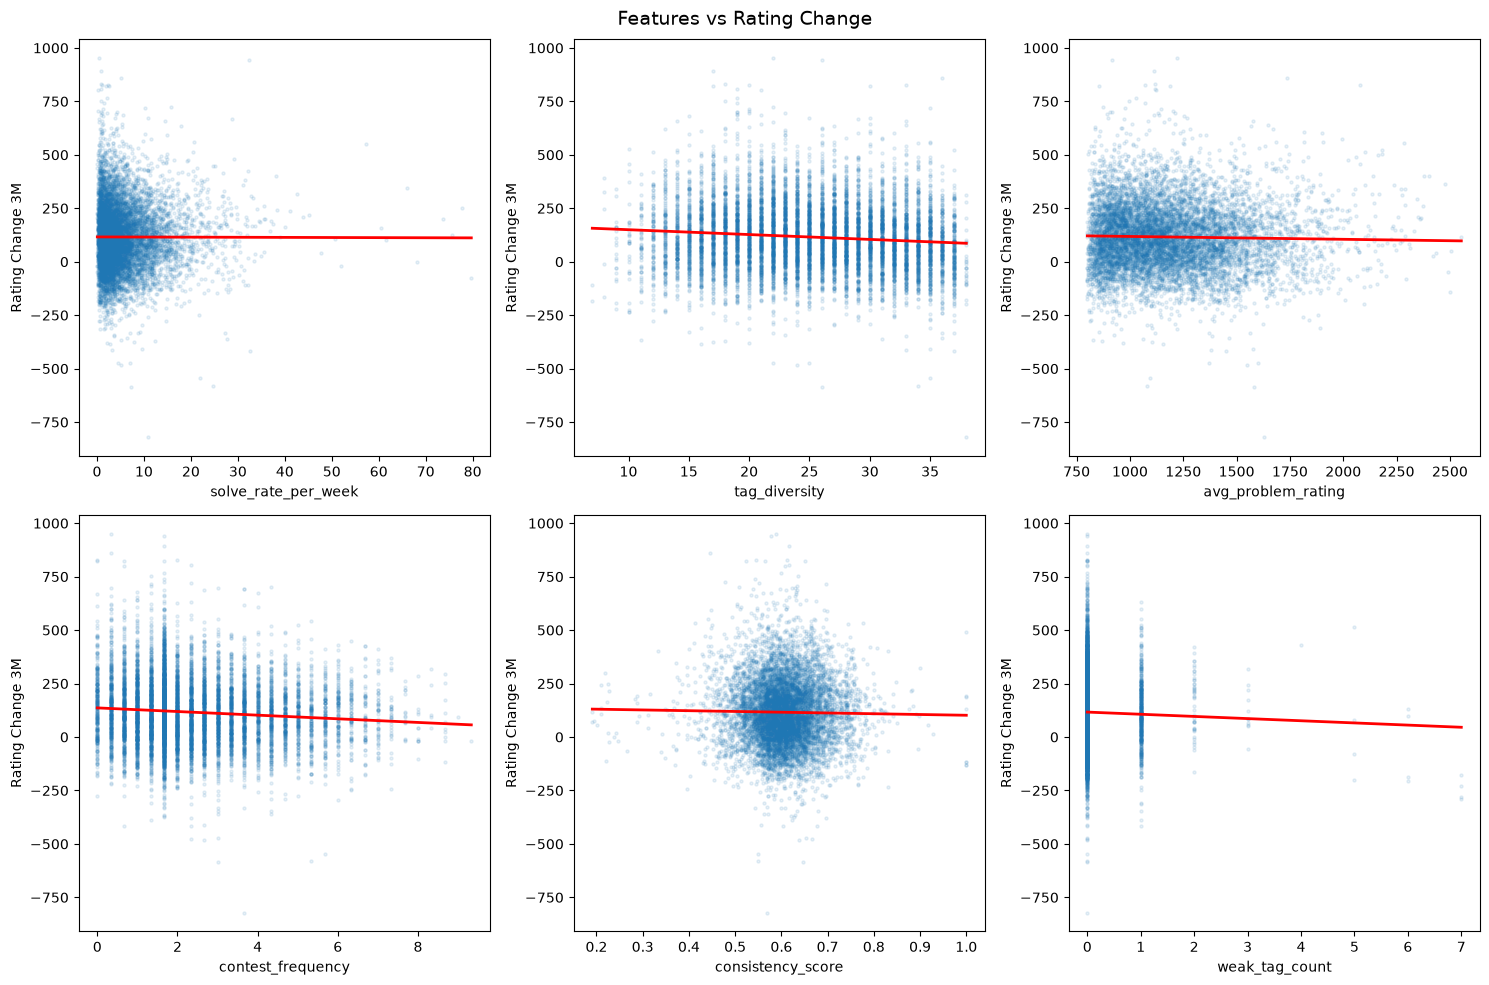

In [6]:
feature_cols = [
    'solve_rate_per_week', 'tag_diversity',
    'avg_problem_rating', 'contest_frequency',
    'consistency_score', 'weak_tag_count'
]

available_features = [f for f in feature_cols if f in df.columns]
df['rating_change'] = df['label_3m'] - df['current_rating']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, feat in zip(axes.flatten(), available_features):
    ax.scatter(df[feat], df['rating_change'], alpha=0.1, s=5)
    ax.set_xlabel(feat)
    ax.set_ylabel('Rating Change 3M')

    # Add trend line
    z = np.polyfit(df[feat].fillna(0), df['rating_change'], 1)
    p = np.poly1d(z)
    ax.plot(
        sorted(df[feat].fillna(0)),
        p(sorted(df[feat].fillna(0))),
        'r-', linewidth=2
    )

plt.suptitle('Features vs Rating Change', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import joblib

# Define feature columns
# Only include columns that actually exist in your dataset
ALL_FEATURES = [
    'current_rating',
    'solve_rate_per_week',
    'tag_diversity',
    'avg_problem_rating',
    'contest_frequency',
    'consistency_score',
    'weak_tag_count',
    'rating_volatility',
    'recent_performance',
    'total_ac_count'
]

# Use only available columns
FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f"Using {len(FEATURES)} features: {FEATURES}")

# Targets
TARGET_3M = 'label_3m'
TARGET_6M = 'label_6m'

X     = df[FEATURES].fillna(0)
y_3m  = df[TARGET_3M]
y_6m  = df[TARGET_6M] if TARGET_6M in df.columns else y_3m

print(f"\nX shape: {X.shape}")
print(f"y_3m shape: {y_3m.shape}")

Using 10 features: ['current_rating', 'solve_rate_per_week', 'tag_diversity', 'avg_problem_rating', 'contest_frequency', 'consistency_score', 'weak_tag_count', 'rating_volatility', 'recent_performance', 'total_ac_count']

X shape: (8637, 10)
y_3m shape: (8637,)


In [8]:
# Split data
# Use random_state for reproducibility
X_train, X_test, y_train_3m, y_test_3m = train_test_split(
    X, y_3m,
    test_size    = 0.20,
    random_state = 42
)

_, _, y_train_6m, y_test_6m = train_test_split(
    X, y_6m,
    test_size    = 0.20,
    random_state = 42
)

print(f"Training set:   {len(X_train)} rows")
print(f"Test set:       {len(X_test)} rows")
print()
print(f"Training rating range: {y_train_3m.min():.0f} – {y_train_3m.max():.0f}")
print(f"Test rating range:     {y_test_3m.min():.0f} – {y_test_3m.max():.0f}")

Training set:   6909 rows
Test set:       1728 rows

Training rating range: 471 – 3513
Test rating range:     563 – 2981


In [9]:
print("Training 3-month rating prediction model...")
print()

model_3m = XGBRegressor(
    n_estimators       = 500,
    max_depth          = 6,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 3,
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    random_state       = 42,
    eval_metric        = 'mae',
    early_stopping_rounds = 30,
    verbosity          = 0
)

model_3m.fit(
    X_train,
    y_train_3m,
    eval_set       = [(X_test, y_test_3m)],
    verbose        = False
)

# Evaluate on test set
preds_3m = model_3m.predict(X_test)

mae_3m  = mean_absolute_error(y_test_3m, preds_3m)
rmse_3m = mean_squared_error(y_test_3m, preds_3m) ** 0.5
r2_3m   = r2_score(y_test_3m, preds_3m)

print("=== 3-Month Model Results ===")
print(f"MAE:   {mae_3m:.1f} rating points")
print(f"RMSE:  {rmse_3m:.1f} rating points")
print(f"R²:    {r2_3m:.3f}")
print()
print(f"Interpretation:")
print(f"  On average, predictions are off by ±{mae_3m:.0f} rating points")
print(f"  95% of predictions within ±{mae_3m*2:.0f} rating points")

Training 3-month rating prediction model...

=== 3-Month Model Results ===
MAE:   112.7 rating points
RMSE:  143.3 rating points
R²:    0.855

Interpretation:
  On average, predictions are off by ±113 rating points
  95% of predictions within ±225 rating points


In [10]:
print("Training 6-month rating prediction model...")
print()

model_6m = XGBRegressor(
    n_estimators       = 500,
    max_depth          = 6,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 3,
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    random_state       = 42,
    eval_metric        = 'mae',
    early_stopping_rounds = 30,
    verbosity          = 0
)

model_6m.fit(
    X_train,
    y_train_6m,
    eval_set       = [(X_test, y_test_6m)],
    verbose        = False
)

preds_6m = model_6m.predict(X_test)

mae_6m  = mean_absolute_error(y_test_6m, preds_6m)
rmse_6m = mean_squared_error(y_test_6m, preds_6m) ** 0.5
r2_6m   = r2_score(y_test_6m, preds_6m)

print("=== 6-Month Model Results ===")
print(f"MAE:   {mae_6m:.1f} rating points")
print(f"RMSE:  {rmse_6m:.1f} rating points")
print(f"R²:    {r2_6m:.3f}")

Training 6-month rating prediction model...

=== 6-Month Model Results ===
MAE:   135.4 rating points
RMSE:  172.2 rating points
R²:    0.794


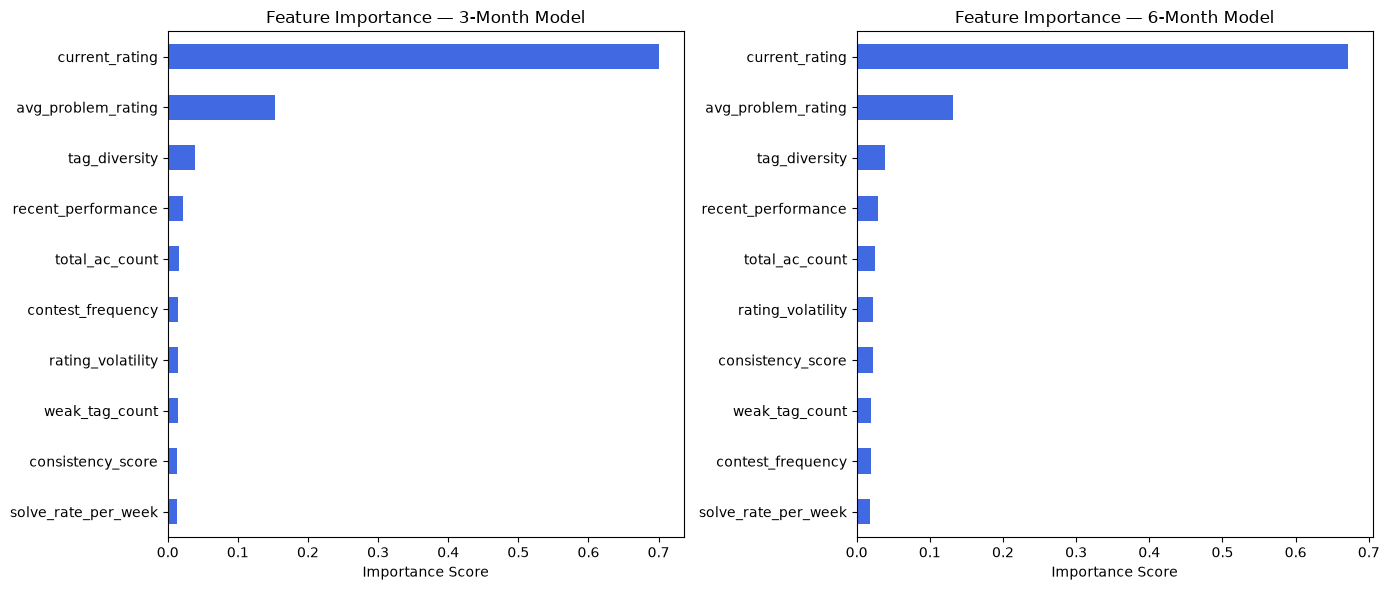

Top features for 3-month prediction:
  current_rating           : 0.7011  ██████████████████████████████████████████████████████████████████████
  avg_problem_rating       : 0.1529  ███████████████
  tag_diversity            : 0.0392  ███
  recent_performance       : 0.0214  ██
  total_ac_count           : 0.0157  █
  contest_frequency        : 0.0146  █
  rating_volatility        : 0.0144  █
  weak_tag_count           : 0.0141  █
  consistency_score        : 0.0138  █
  solve_rate_per_week      : 0.0130  █


In [11]:
# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, title in [
    (axes[0], model_3m, '3-Month Model'),
    (axes[1], model_6m, '6-Month Model')
]:
    importance = pd.Series(
        model.feature_importances_,
        index=FEATURES
    ).sort_values(ascending=True)

    importance.plot(kind='barh', ax=ax, color='royalblue')
    ax.set_title(f'Feature Importance — {title}')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print("Top features for 3-month prediction:")
imp = pd.Series(
    model_3m.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)
for feat, score in imp.items():
    bar = '█' * int(score * 100)
    print(f"  {feat:25s}: {score:.4f}  {bar}")

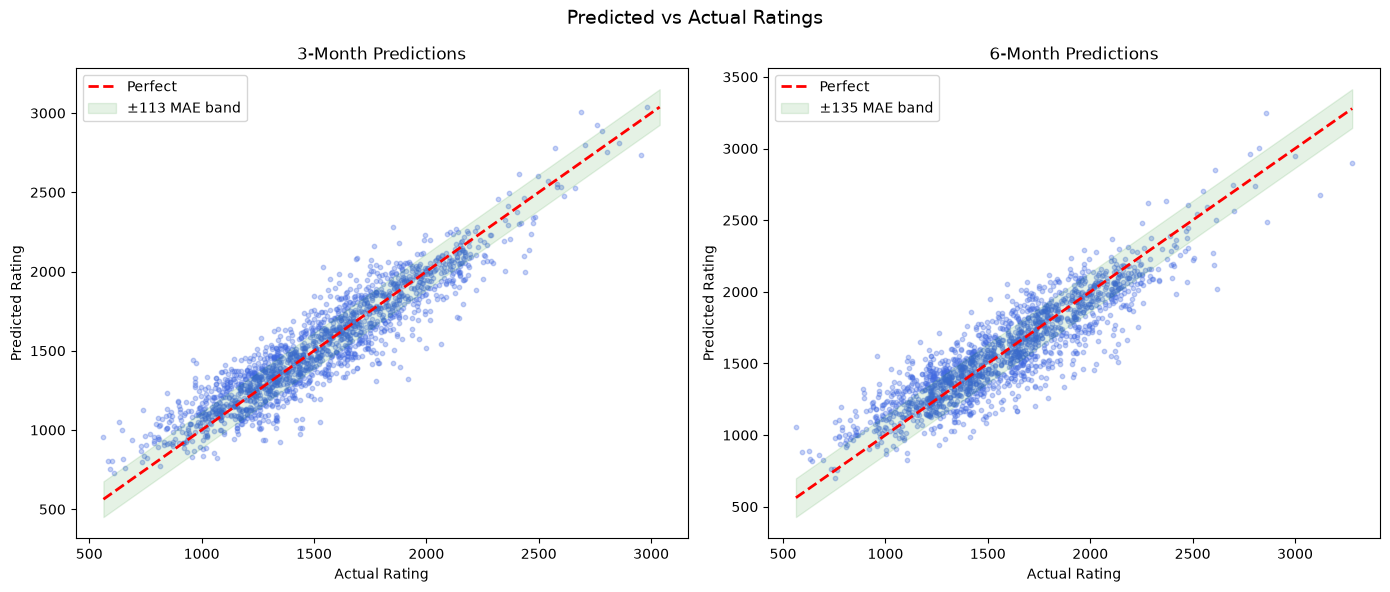

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, preds, actuals, mae, title in [
    (axes[0], preds_3m, y_test_3m, mae_3m, '3-Month Predictions'),
    (axes[1], preds_6m, y_test_6m, mae_6m, '6-Month Predictions')
]:
    ax.scatter(actuals, preds, alpha=0.3, s=10, color='royalblue')

    # Perfect prediction line
    min_val = min(actuals.min(), preds.min())
    max_val = max(actuals.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')

    # MAE bands
    ax.fill_between(
        [min_val, max_val],
        [min_val - mae, max_val - mae],
        [min_val + mae, max_val + mae],
        alpha=0.1, color='green', label=f'±{mae:.0f} MAE band'
    )

    ax.set_xlabel('Actual Rating')
    ax.set_ylabel('Predicted Rating')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Predicted vs Actual Ratings', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
print("Running 5-fold cross-validation...")
print("(This is the honest evaluation — not just one train/test split)")
print()

cv_scores_3m = cross_val_score(
    XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        verbosity=0
    ),
    X, y_3m,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

cv_mae_3m = -cv_scores_3m

print(f"3-Month Cross-Validation MAE:")
print(f"  Per fold:  {cv_mae_3m}")
print(f"  Mean:      {cv_mae_3m.mean():.1f} ± {cv_mae_3m.std():.1f} rating points")
print()
print(f"This means your predictions are off by {cv_mae_3m.mean():.0f} rating points on average")
print(f"Your prediction range should be: predicted ± {cv_mae_3m.mean():.0f}")

Running 5-fold cross-validation...
(This is the honest evaluation — not just one train/test split)

3-Month Cross-Validation MAE:
  Per fold:  [129.58007812 113.16605377 118.14198303 122.10162354 128.46891785]
  Mean:      122.3 ± 6.2 rating points

This means your predictions are off by 122 rating points on average
Your prediction range should be: predicted ± 122


In [14]:
import joblib
import json
import os

# Create models directory
os.makedirs('../models', exist_ok=True)

# Save models
joblib.dump(model_3m, '../models/rating_model_3m.pkl')
joblib.dump(model_6m, '../models/rating_model_6m.pkl')
print("✅ Models saved")

# Save feature list and MAE values
# These are loaded by the backend at runtime
model_metadata = {
    "features":   FEATURES,
    "mae_3m":     float(cv_mae_3m.mean()),
    "mae_6m":     float(mae_6m),
    "rmse_3m":    float(rmse_3m),
    "r2_3m":      float(r2_3m),
    "n_training": len(X_train),
    "n_test":     len(X_test)
}

with open('../models/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("✅ Metadata saved")
print()
print("Saved files:")
print("  models/rating_model_3m.pkl")
print("  models/rating_model_6m.pkl")
print("  models/model_metadata.json")
print()
print(f"Final Summary:")
print(f"  3-Month MAE:  {cv_mae_3m.mean():.1f} rating points")
print(f"  6-Month MAE:  {mae_6m:.1f} rating points")
print(f"  Training rows: {len(X_train)}")

✅ Models saved
✅ Metadata saved

Saved files:
  models/rating_model_3m.pkl
  models/rating_model_6m.pkl
  models/model_metadata.json

Final Summary:
  3-Month MAE:  122.3 rating points
  6-Month MAE:  135.4 rating points
  Training rows: 6909
